# Imports

In [1]:
import os
import sys

import numpy as np
import torch
from torchvision.transforms import GaussianBlur
from IPython.core.pylabtools import figsize
from mpmath.identification import transforms
import matplotlib.pyplot as plt
from torchvision.transforms.v2 import RandomApply

from utils.checkpoint import load_checkpoint, save_checkpoint
from utils.data import get_dataloaders, get_img_from_loader
from evaluate import evaluate, evaluate_with_uncertainty

sys.path.append("..")

from models.lenet import Net as LeNet
from config import Config

from utils.corruptions import gaussian_blur, test_on_corruptions, corruptions_uncertainty
from utils.data import get_img_from_loader



In [2]:
import math

config = Config()
device = config.device

# Prepare data
_, val_loader, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
)

# Model
lenet_model = LeNet(
    prior_sigma1=math.exp(0),
    prior_sigma2=math.exp(-6),
    prior_pi=0.5,
    num_classes=10,
    rho_init=-4.5
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(lenet_model.parameters(), lr=config.learning_rate)
# Load weights
# config.model_name = 'mnist_bayesian_lenet'
config.model_name = 'lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1'
epoch = load_checkpoint(lenet_model, optimizer, f'{config.checkpoint_path}/{config.model_name}/{config.get_checkpoint_name(190, date="20260129")}', device)
# load_checkpoint(lenet_model, optimizer, f'{config.checkpoint_path}/{config.get_checkpoint_name(475, date="20251201")}', device)


[checkpoint] Loaded from ../checkpoints/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1_epoch_190_20260129.pth, starting at epoch 191


# Corruptions

In [3]:
torch.manual_seed(42)
corruptions = {
    'Original': lambda x: x,
    '$k=3$': lambda x: gaussian_blur(x, kernel_size=3),
    '$k=5$': lambda x: gaussian_blur(x, kernel_size=5),
    '$k=7$': lambda x: gaussian_blur(x, kernel_size=7),
    '$k=9$': lambda x: gaussian_blur(x, kernel_size=9),
}
T = 10

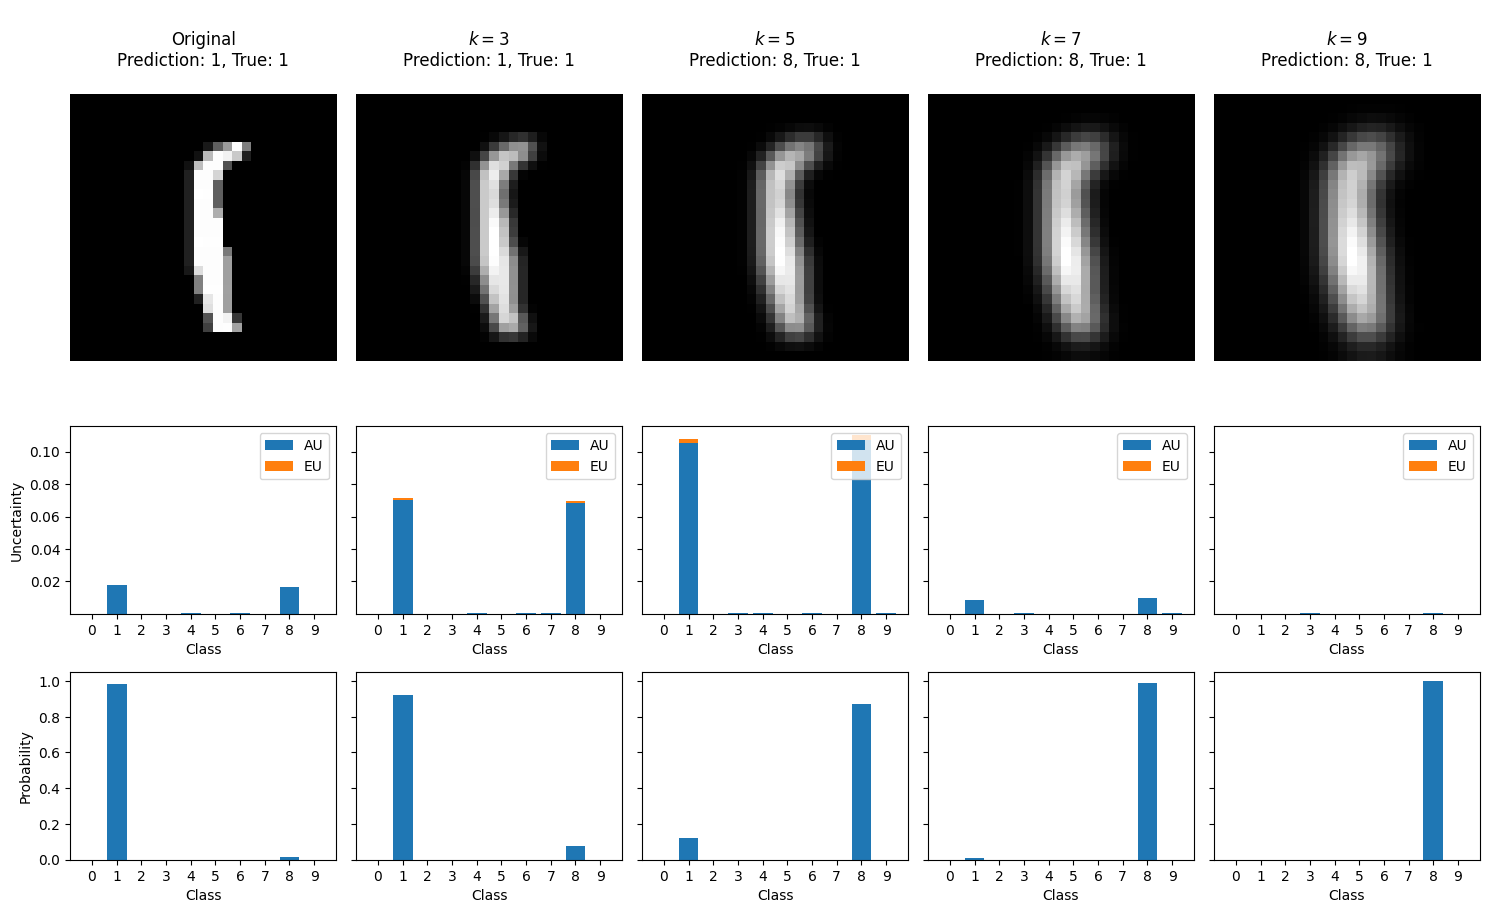

In [4]:
img, label = get_img_from_loader(test_loader, batch_idx=29, img_idx=3, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, T)

Random batch index: 435, image index: 0


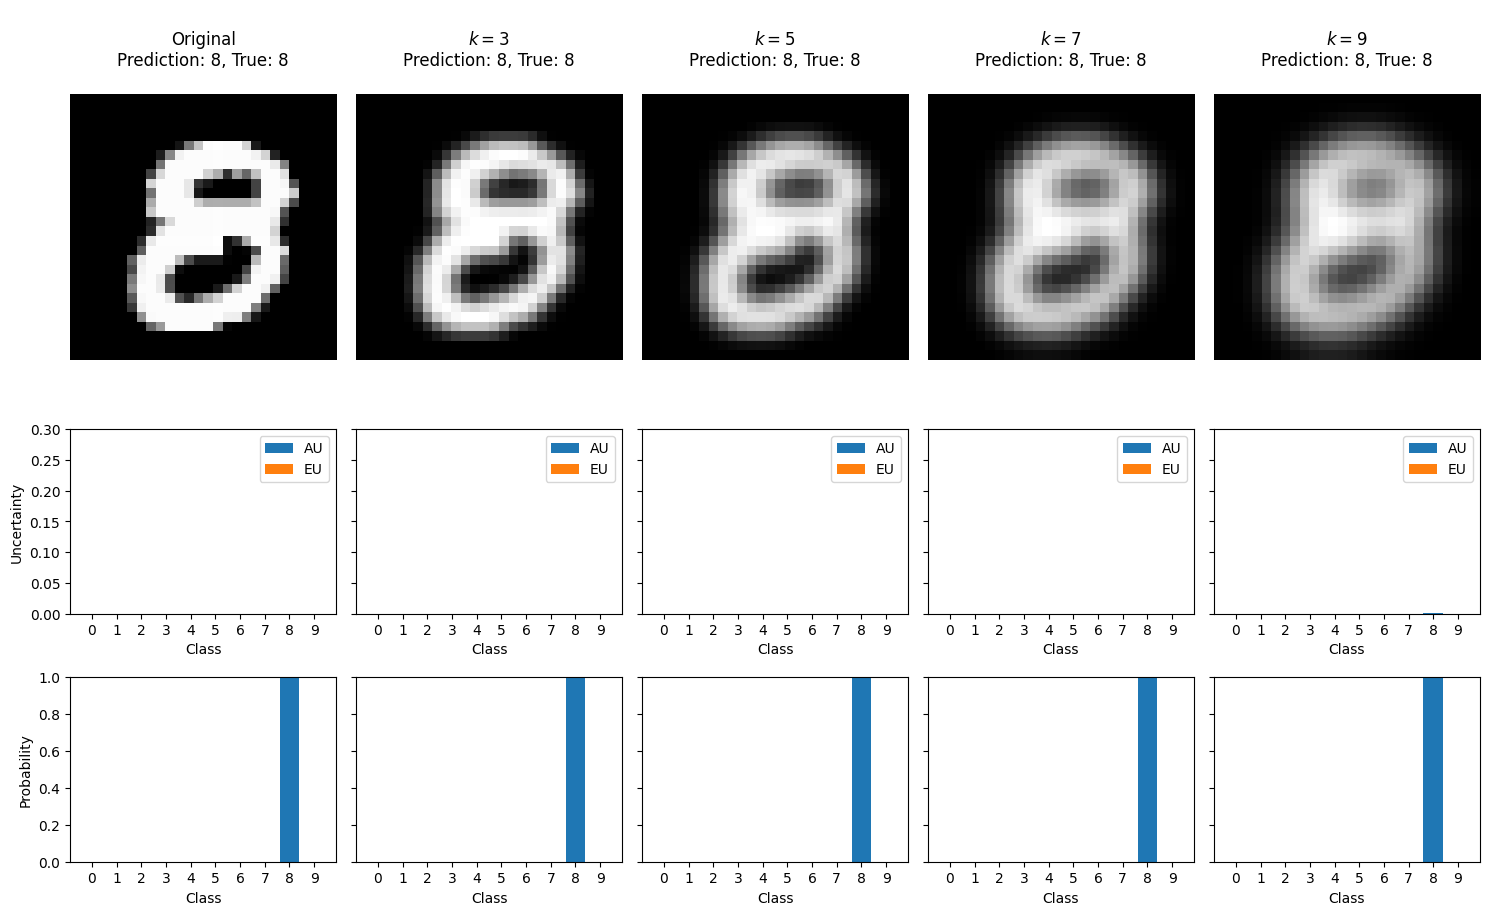

In [12]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, T=10)

# Вычисление точности с гауссовским размытием

In [4]:
from tqdm import tqdm

kernel_sizes = [0, 3, 5, 7, 9]
accuracies = []
total_unc = []
alea_unc = []
epis_unc = []

original_test_accuracy = evaluate(lenet_model, test_loader, device=config.device)
_, uncertainties = evaluate_with_uncertainty(lenet_model, test_loader, device=config.device, mc_samples=10)
accuracies.append(original_test_accuracy)
total_unc.append(uncertainties[0].mean().item())
alea_unc.append(uncertainties[1].mean().item())
epis_unc.append(uncertainties[2].mean().item())

loop = tqdm(kernel_sizes[1:], desc=f"Calculating Accuracy and Uncertainties with Gaussian Blur")
for kernel_size in loop:
    blurred_test_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        extra_transforms=[
            # RandomApply([GaussianBlur(kernel_size)], p=0.75),
            GaussianBlur(kernel_size)
        ]
    )[2]  # Получаем только тестовый загрузчик

    test_accuracy = evaluate(lenet_model, blurred_test_loader, device=config.device)
    _, uncertainties = evaluate_with_uncertainty(lenet_model, blurred_test_loader, device=config.device, mc_samples=10)
    accuracies.append(test_accuracy)
    total_unc.append(uncertainties[0].mean().item())
    alea_unc.append(uncertainties[1].mean().item())
    epis_unc.append(uncertainties[2].mean().item())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(kernel_sizes, accuracies)
axes[0].set_title("Accuracy vs Kernel size")
axes[0].set_ylabel("Accuracy")

axes[1].plot(kernel_sizes, total_unc, label='TU')
axes[1].plot(kernel_sizes, alea_unc, label='AU')
axes[1].plot(kernel_sizes, epis_unc, label='EU')
axes[1].set_title("Uncertainties vs Kernel size")
axes[1].set_ylabel("Uncertainties")
axes[1].legend()

for i in range(2):
    axes[i].set_xlabel("Kernel size")
plt.show()

KeyboardInterrupt: 

# Распределение неопределенностей разных классов на разных искажениях

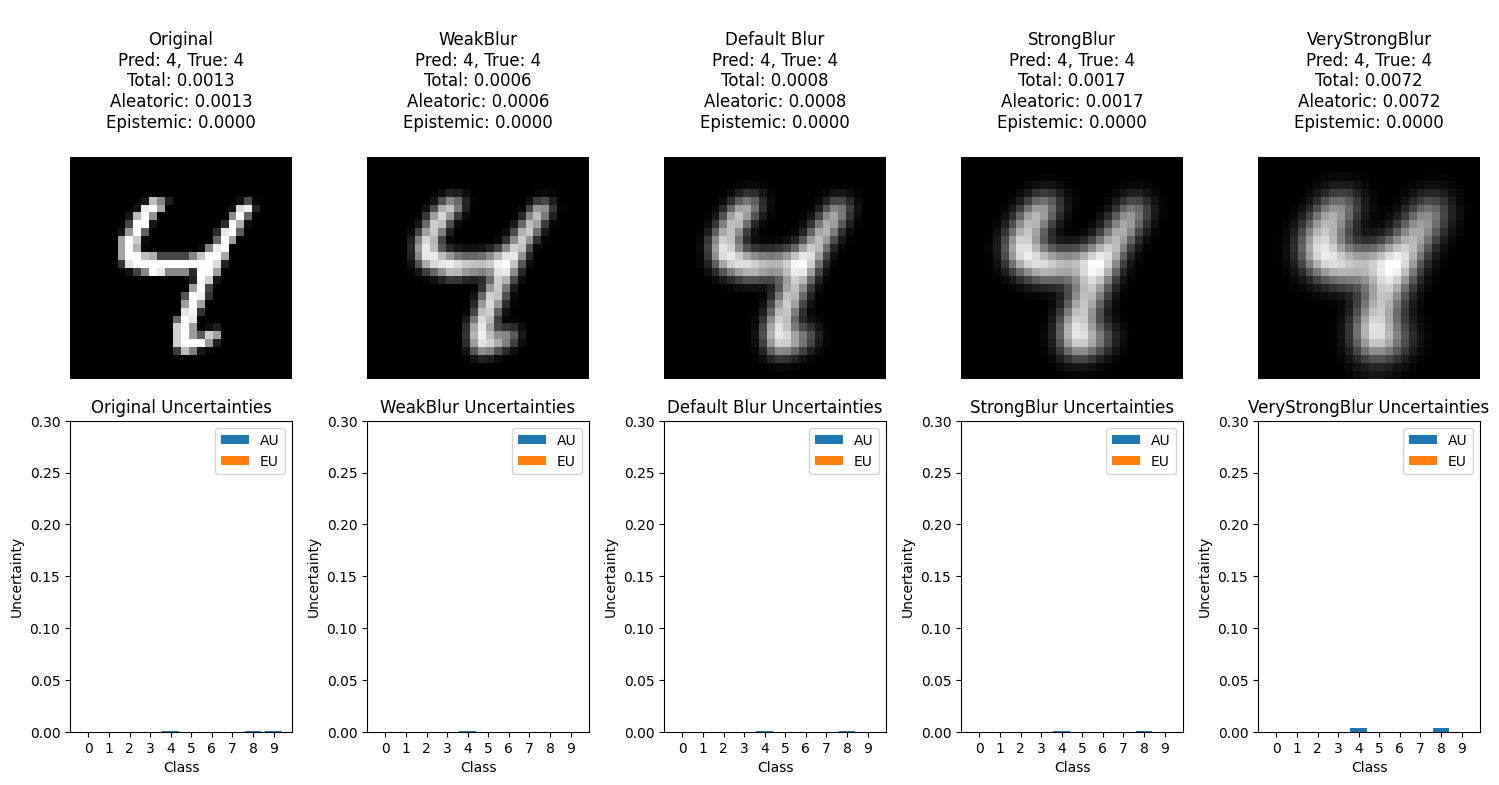

In [35]:
img, label = get_img_from_loader(test_loader, batch_idx=0, img_idx=6, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, T=10)

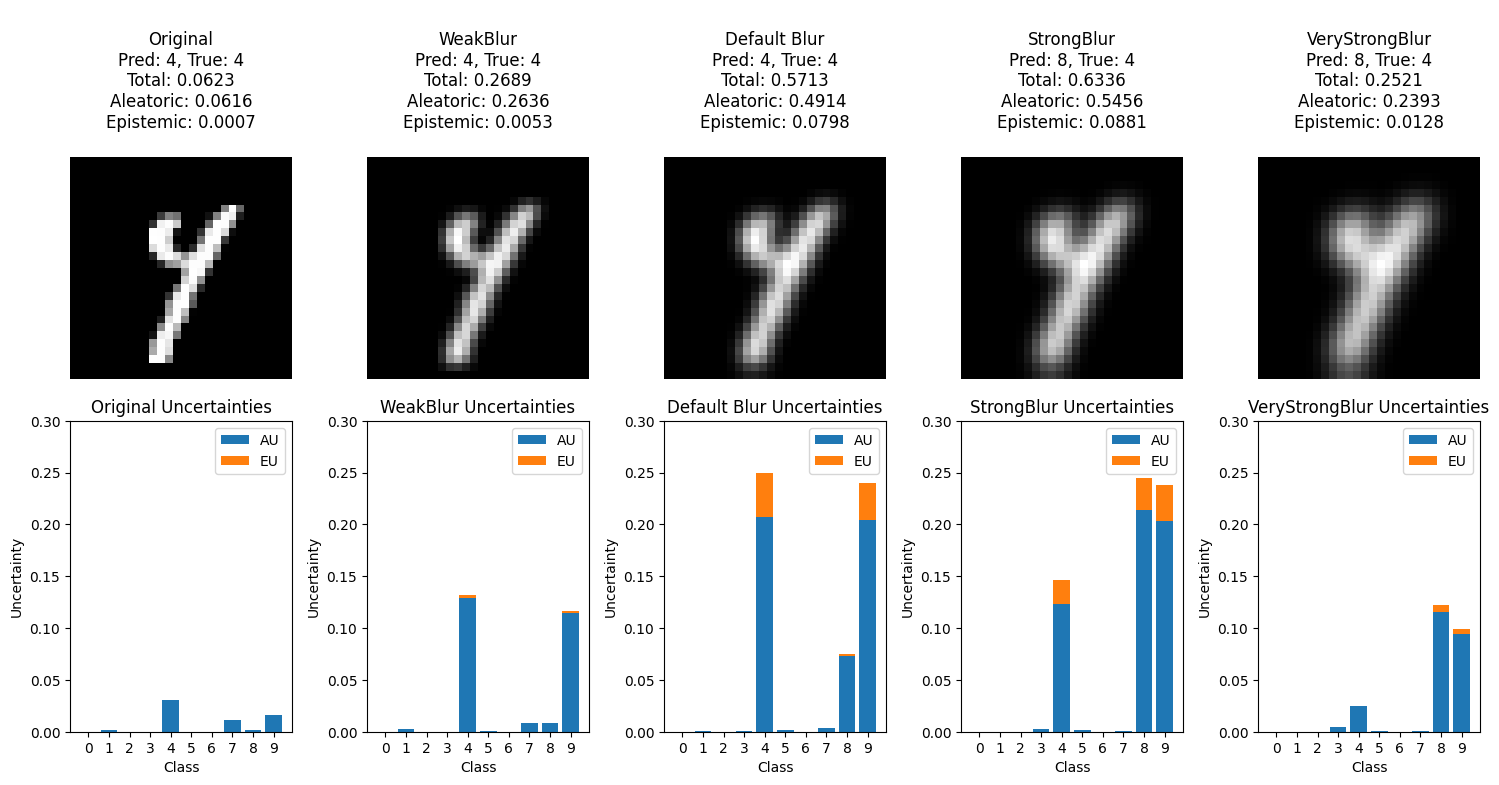

In [36]:
img, label = get_img_from_loader(test_loader, batch_idx=116, img_idx=10, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, T=10)


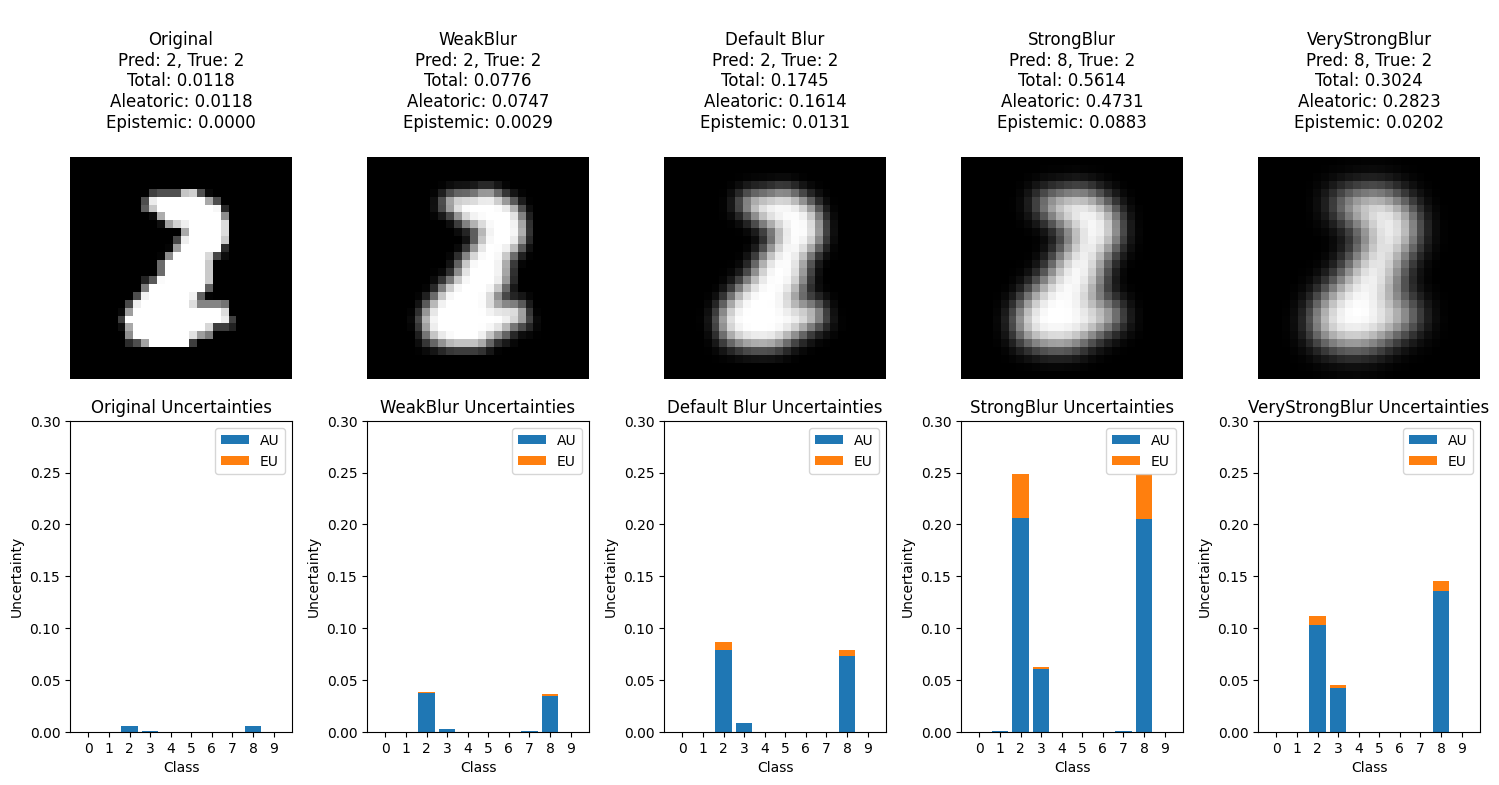

In [38]:
img, label = get_img_from_loader(test_loader, batch_idx=133, img_idx=9, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, T=10)


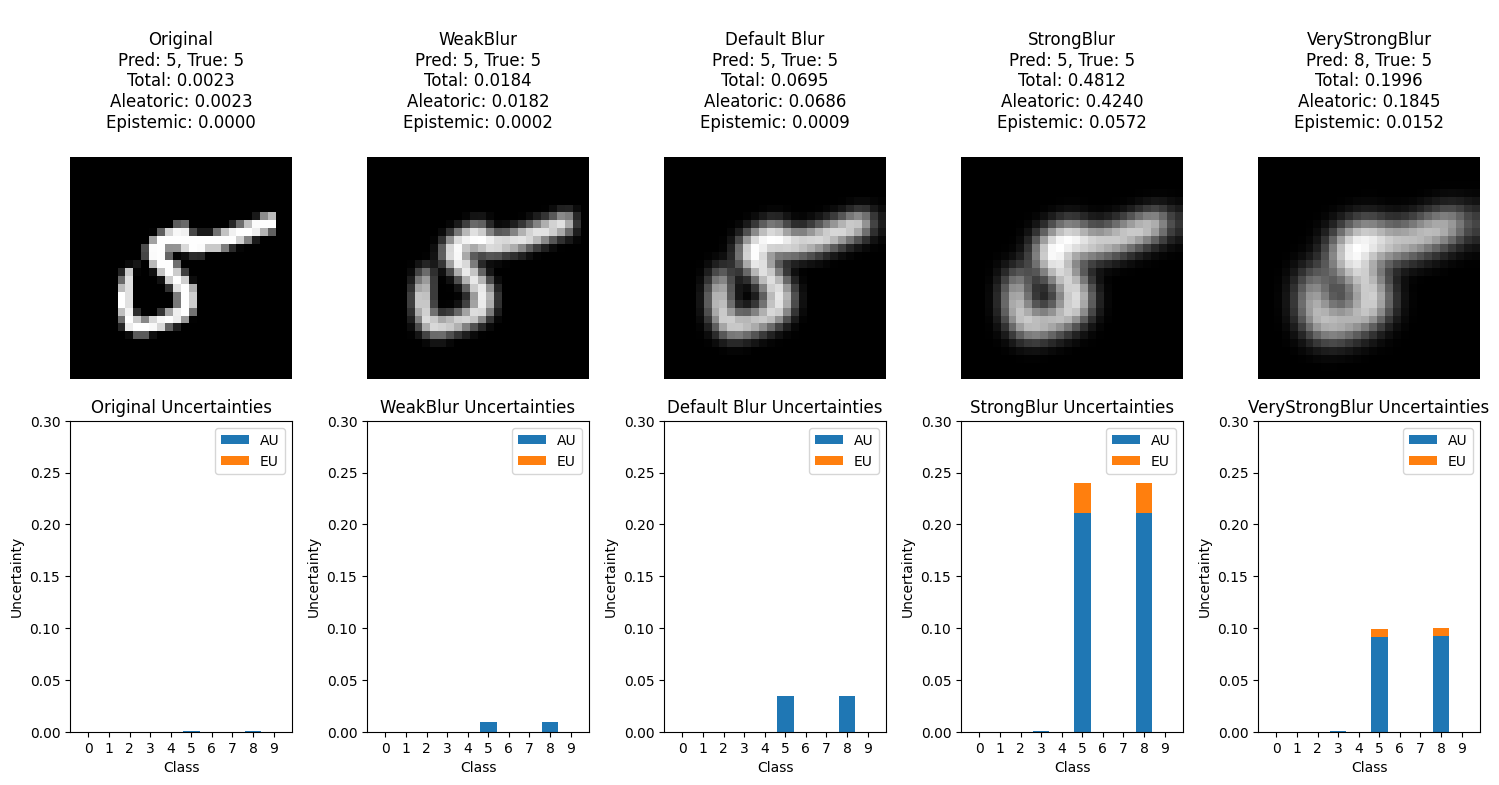

In [40]:
img, label = get_img_from_loader(test_loader, batch_idx=592, img_idx=11, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, T=10)

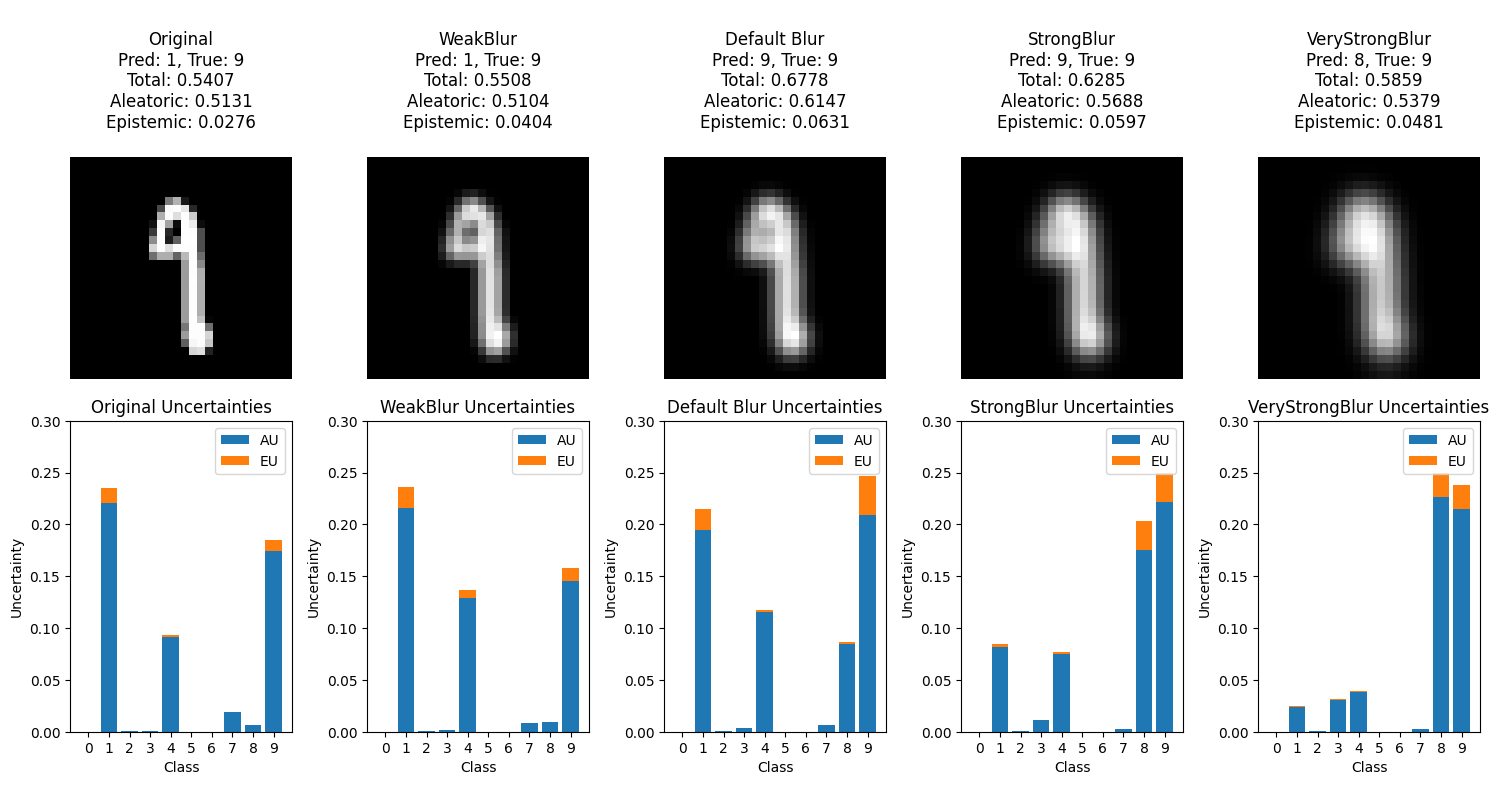

In [41]:
img, label = get_img_from_loader(test_loader, batch_idx=170, img_idx=7, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, T=10)

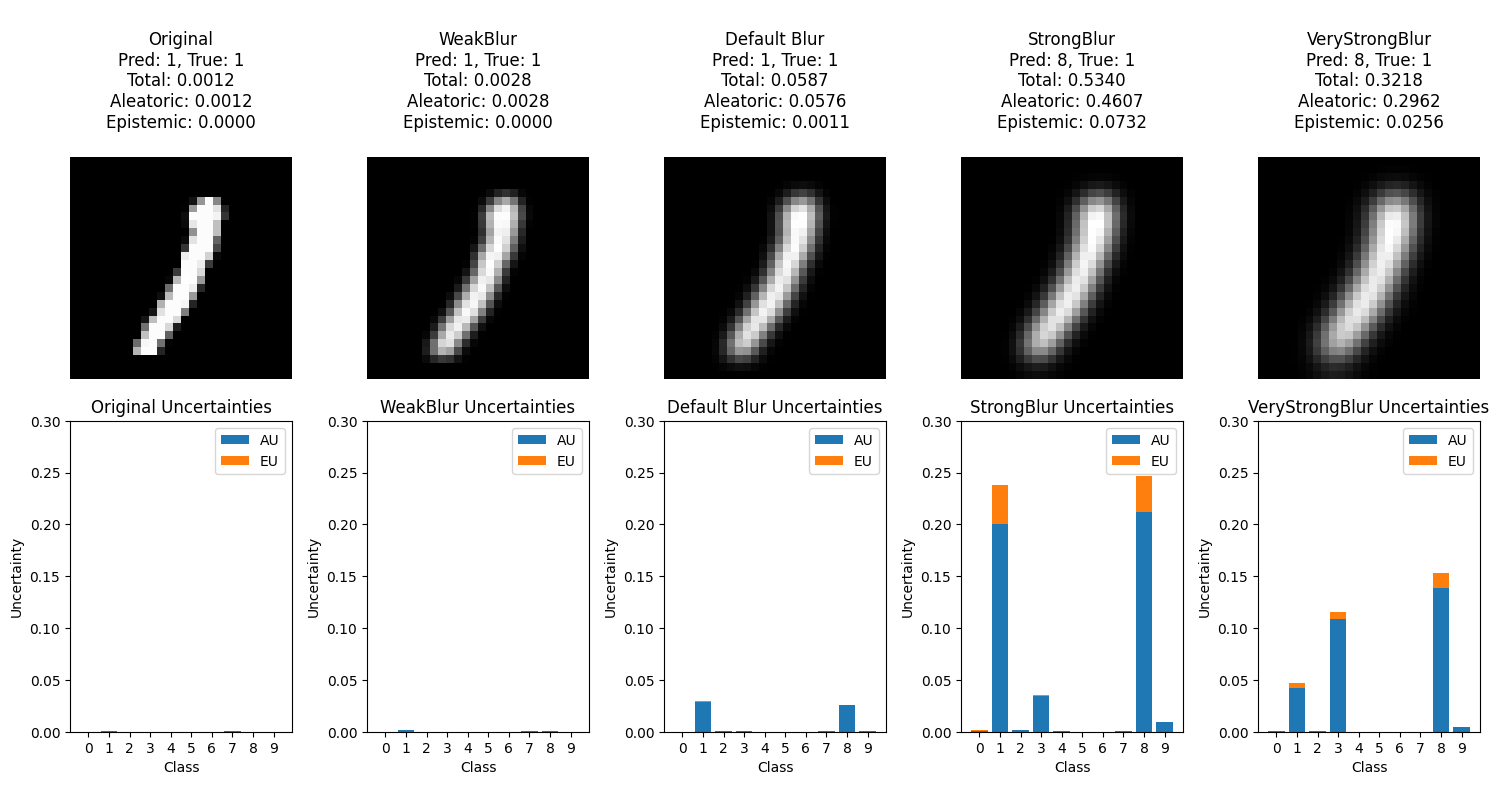

In [63]:
img, label = get_img_from_loader(test_loader, batch_idx=220, img_idx=12, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, T=10)

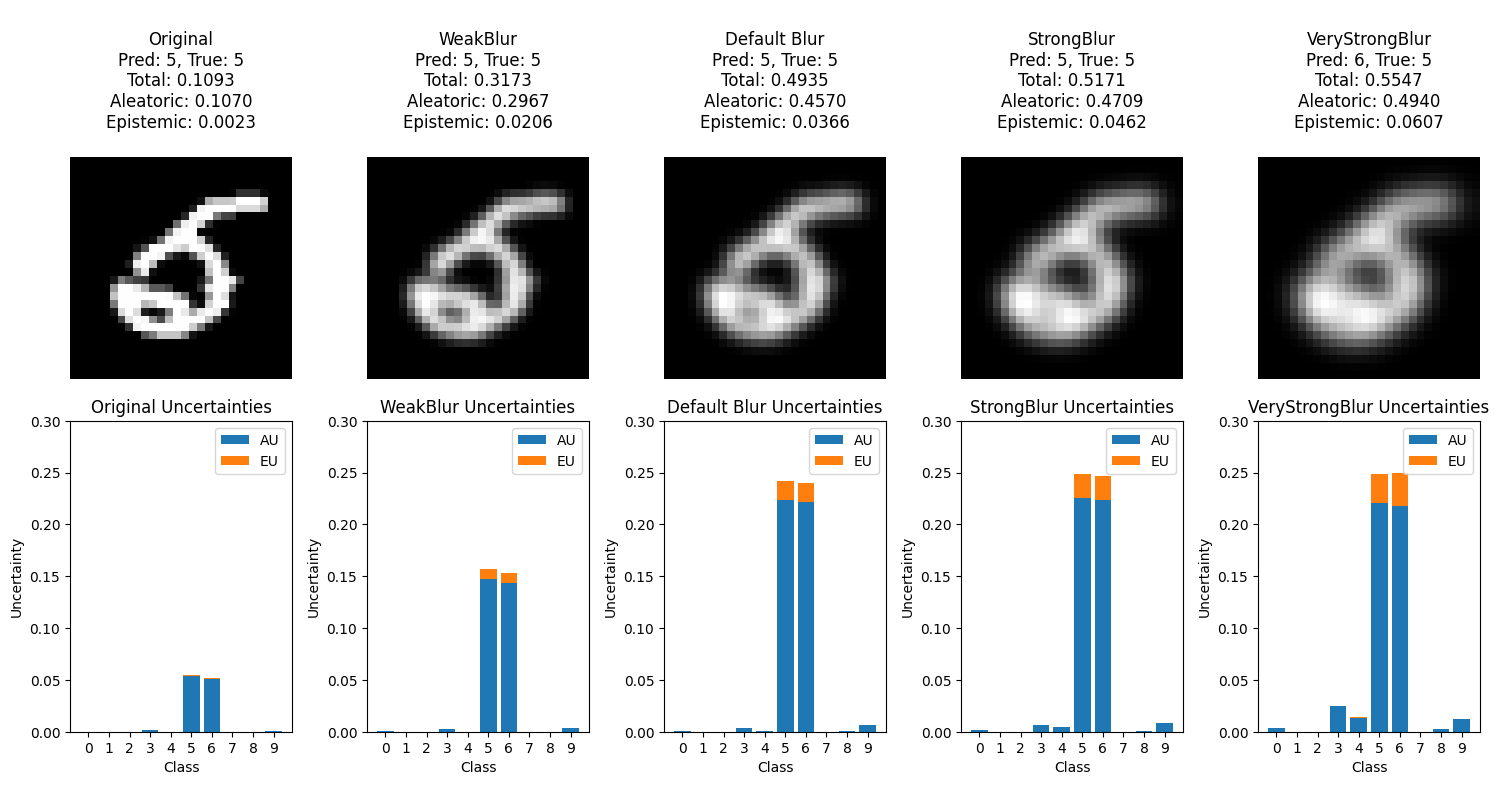

In [83]:
img, label = get_img_from_loader(test_loader, batch_idx=696, img_idx=5, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, T=10)

Random batch index: 608, image index: 12


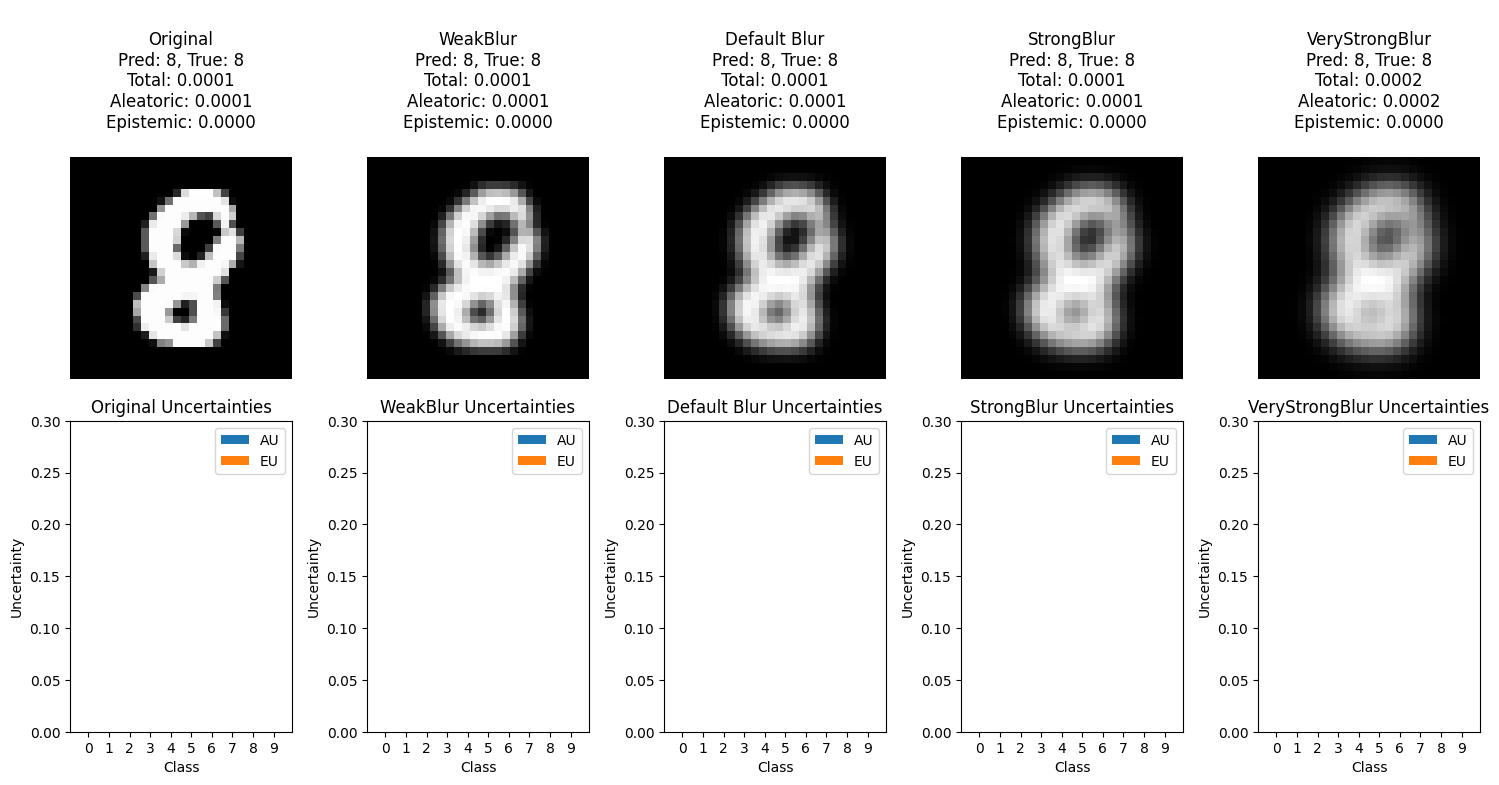

In [112]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
corruptions_uncertainty(lenet_model, img, label, corruptions, T=10)

# Тестирование неопределенности на разных искажениях

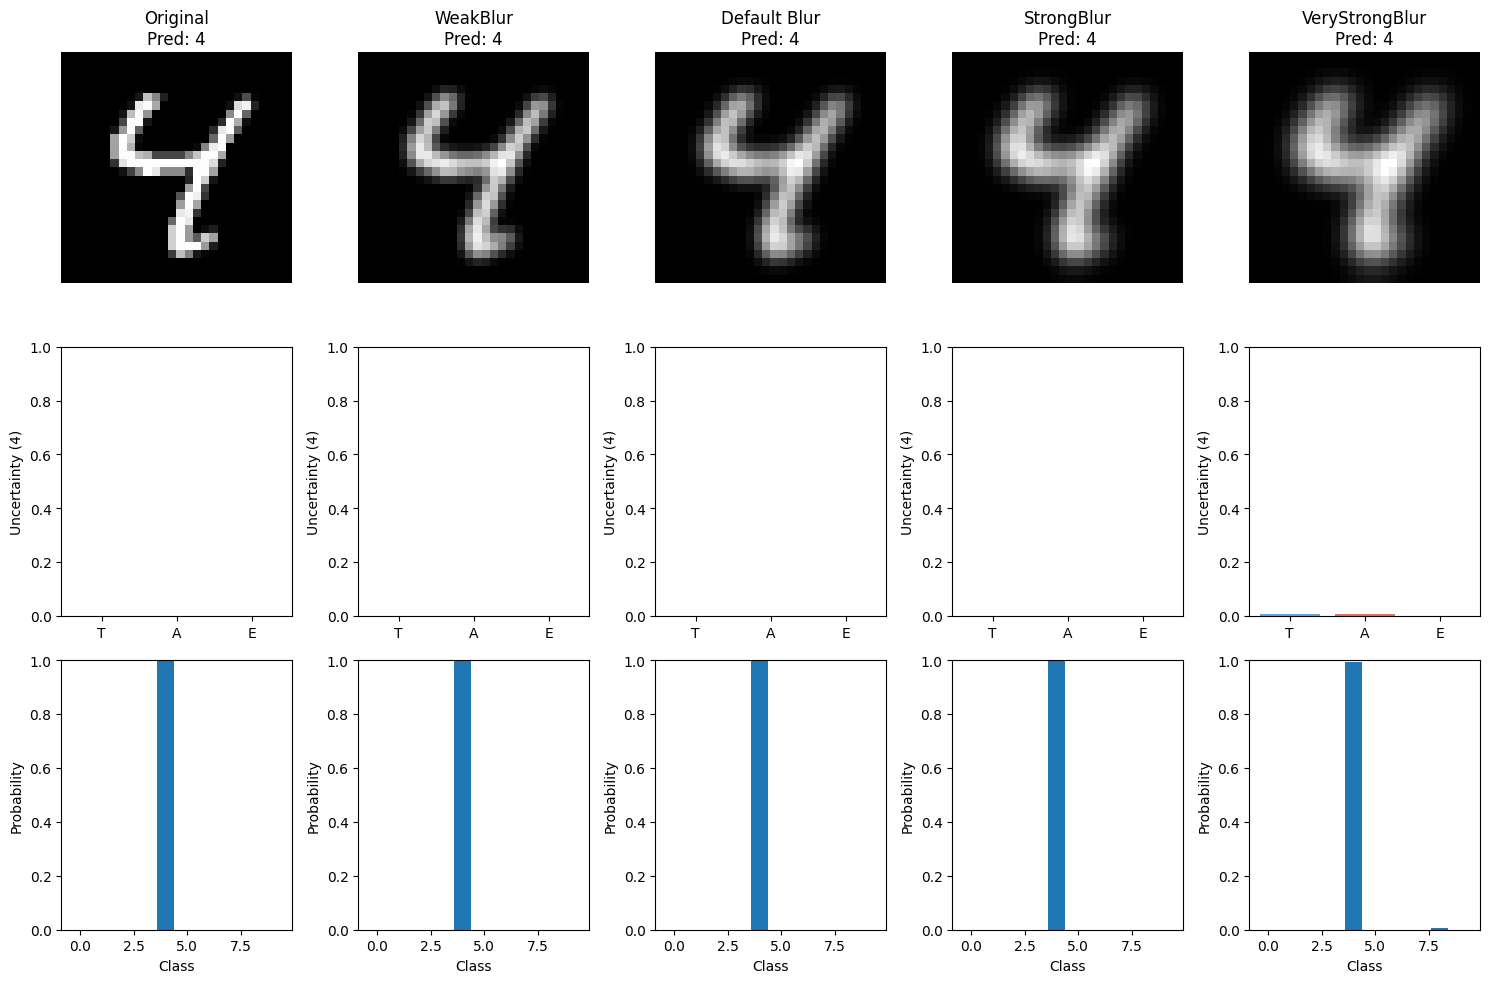

In [6]:
img, label = get_img_from_loader(test_loader, batch_idx=0, img_idx=6, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label,), T=10)

Random batch index: 489, image index: 11


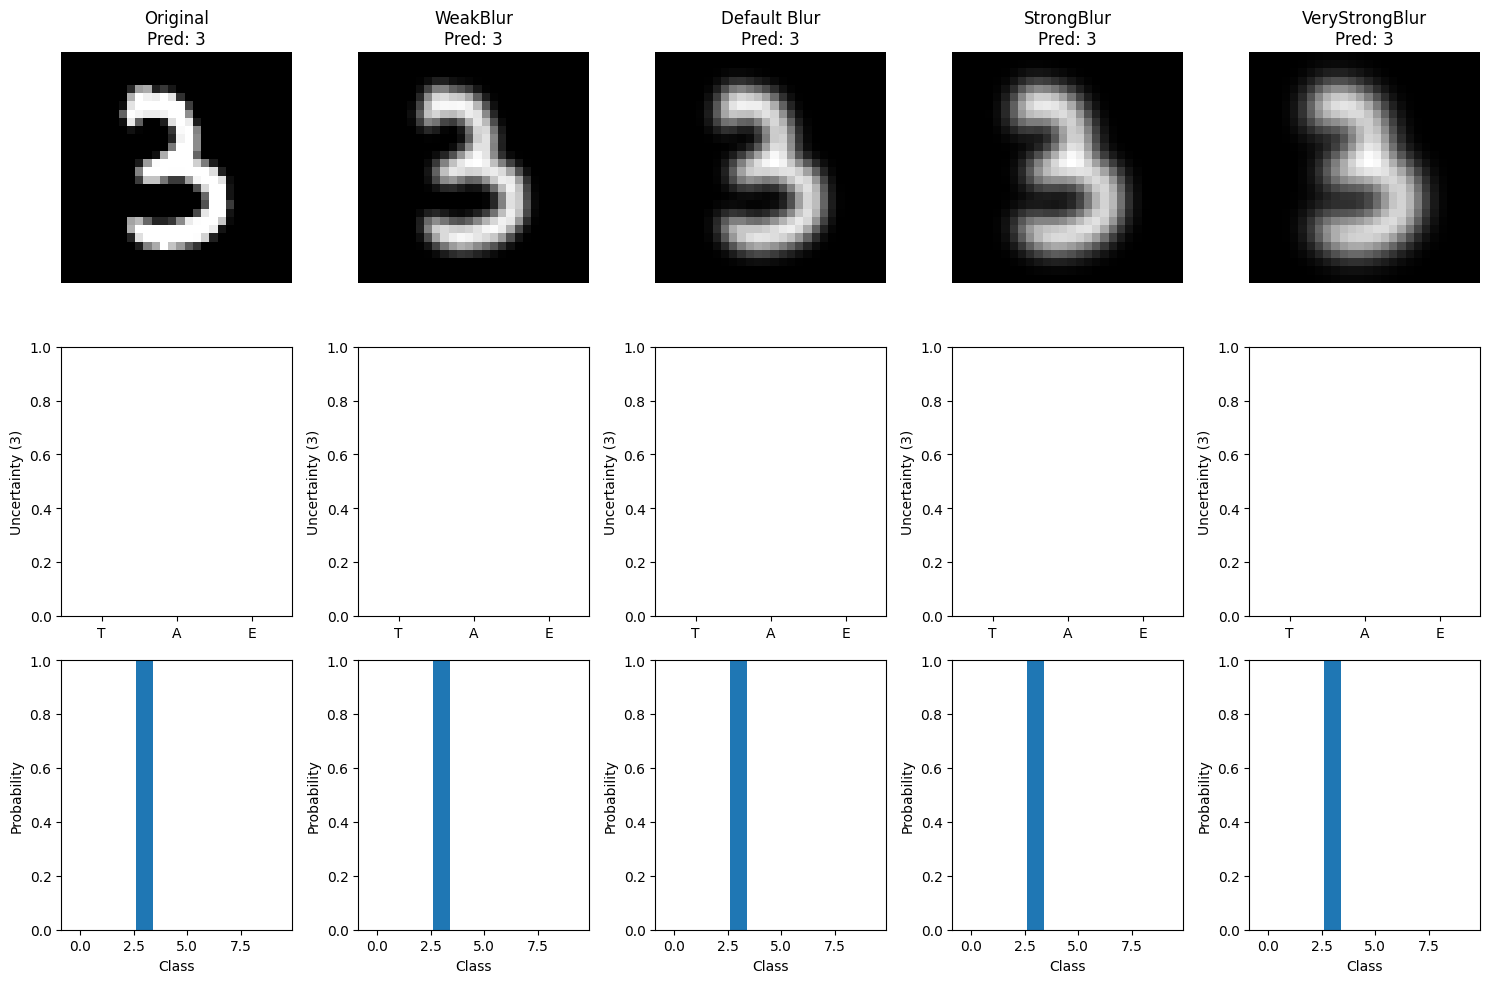

In [7]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label,), T=10)

In [69]:
from matplotlib import pyplot as plt
from utils.uncertainty import mc_predict, quantify_uncertainties
from utils.corruptions import gaussian_blur

def corruptions_and_uncertainties_plot(model, img, label, corruptions: dict = None, T=5):
    """Зависимость алеаторной неопределенности от типа и степени искажения изображения."""

    assert corruptions is not None

    # Словарь: {class_label: {corruption_name: uncertainty_value}}
    data = {
        'true': dict(),
        'pred': dict()
    }

    for col, (name, corrupt_fn) in enumerate(corruptions.items()):
        corrupted = corrupt_fn(img).unsqueeze(0)
        mc_preds = mc_predict(model, corrupted, mc_samples=T)
        mean_probs = mc_preds.mean(dim=0).squeeze(0)
        pred, (_, alea, _) = quantify_uncertainties(mc_preds)

        # Для истинного класса
        true_prob = mean_probs[label].item()
        true_alea = alea[0, label, label].item()
        data['true'][name] = true_alea / true_prob

        # Для предсказанного класса
        pred_prob = mean_probs[pred].item()
        pred_alea = alea[0, pred, pred].item()
        data['pred'][name] = pred_alea / pred_prob

    # Визуализация
    fig, axes = plt.subplots(1, 2)
    # Изображение
    axes[0].imshow(img.cpu().squeeze(), cmap='gray')
    axes[0].set_title(f'Number {label}')
    axes[0].axis('off')

    ax = axes[1]
    corruption_names = list(corruptions.keys())

    true_values = [data['true'][name] for name in corruption_names]
    pred_values = [data['pred'][name] for name in corruption_names]

    ax.plot(corruption_names, true_values, marker='o', label=f'True')
    ax.plot(corruption_names, pred_values, marker='s', label=f'Pred')

    ax.set_ylabel('Aleatoric Uncertainty')
    ax.set_xlabel('Corruption Type')
    ax.set_title('Uncertainty: True vs Predicted Class')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [73]:
img, label = get_img_from_loader(test_loader, batch_idx=133, img_idx=9, device=config.device)
corruptions_and_uncertainties_plot(lenet_model, img, label, corruptions, T=10)

In [72]:
img, label = get_img_from_loader(test_loader, batch_idx=133, img_idx=9, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 3, 8), T=10)

In [87]:
img, label = get_img_from_loader(test_loader, batch_idx=265, img_idx=6, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 3), T=10)

In [5]:
img, label = get_img_from_loader(test_loader, batch_idx=43, img_idx=11, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 3, 8), T=10)

In [6]:
img, label = get_img_from_loader(test_loader, batch_idx=695, img_idx=12, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 8), T=10)

In [7]:
img, label = get_img_from_loader(test_loader, batch_idx=688, img_idx=10, device=config.device)
test_on_corruptions(lenet_model, img, corruptions, classes=(label, 6), T=10)

# Зависимость неопределенности модели от правильности предсказаний

In [8]:
# Анализ корреляции между неопределенностью и правильностью предсказаний для разных уровней размытия
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.transforms import GaussianBlur
from utils.uncertainty import mc_predict, quantify_uncertainties

# kernel_sizes = [0, 1, 3, 5, 7, 9]
kernel_sizes = [0, 1, 3, 7]
correlations = []
mean_unc_correct = []
mean_unc_incorrect = []
mean_aunc_correct = []
mean_aunc_incorrect = []
mean_eunc_correct = []
mean_eunc_incorrect = []

lenet_model.eval()

for ks in kernel_sizes:
    if ks == 0:
        current_loader = test_loader
        desc = "Original"
    else:
        current_loader = get_dataloaders(
            data_dir="../data",
            batch_size=config.test_batch_size,
            num_workers=config.num_workers,
            use_cuda=torch.cuda.is_available(),
            extra_transforms=[GaussianBlur(ks)]
        )[2]
        desc = f"Blur {ks}"

    all_correct = []
    all_uncertainties = []
    all_aleatoric = []
    all_epistemic = []

    print(f"Processing {desc}...")
    for x, y in tqdm(current_loader, leave=False):
        x, y = x.to(device), y.to(device)
        
        # Оценка неопределенности
        mc_preds = mc_predict(lenet_model, x, mc_samples=10)
        preds, (total_unc_mat, alea_unc_mat, _) = quantify_uncertainties(mc_preds)
        
        # Извлекаем диагональ (дисперсию для каждого класса) и суммируем
        unc = total_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        aunc = alea_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        correct = (preds == y).float()
        
        all_correct.append(correct.cpu().numpy())
        all_uncertainties.append(unc.cpu().numpy())
        all_aleatoric.append(aunc.cpu().numpy())
        all_epistemic.append((unc - aunc).cpu().numpy())

    c_vec = np.concatenate(all_correct)
    u_vec = np.concatenate(all_uncertainties)
    au_vec = np.concatenate(all_aleatoric)
    eu_vec = np.concatenate(all_epistemic)
    eunc_mean = np.mean(eu_vec)
    aunc_mean = np.mean(au_vec)
    print(f"Kernel {ks}: E[epistemic]={eunc_mean:.6f}, E[aleatoric]={aunc_mean:.6f}, ratio={eunc_mean/aunc_mean:.4f}")

    # Считаем корреляцию
    corr = np.corrcoef(c_vec, u_vec)[0, 1]
    correlations.append(corr)
    
    # Считаем среднюю неопределенность для верных и неверных ответов
    mean_unc_correct.append(u_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mean_unc_incorrect.append(u_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    mean_aunc_correct.append(au_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mean_aunc_incorrect.append(au_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    mean_eunc_correct.append(eu_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mean_eunc_incorrect.append(eu_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)

Processing Original...


Kernel 0: E[epistemic]=0.001154, E[aleatoric]=0.014526, ratio=0.0795
Processing Blur 1...


Kernel 1: E[epistemic]=0.001148, E[aleatoric]=0.014506, ratio=0.0791
Processing Blur 3...


Kernel 3: E[epistemic]=0.001598, E[aleatoric]=0.018572, ratio=0.0860
Processing Blur 7...


Kernel 7: E[epistemic]=0.005854, E[aleatoric]=0.049677, ratio=0.1178


In [ ]:
# Визуализация результатов\n",
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_labels = [str(k) for k in kernel_sizes]
x = np.arange(len(kernel_sizes))
titles = ['Total', 'Aleatoric', 'Epistemic']
incorrect = [mean_unc_incorrect, mean_aunc_incorrect, mean_eunc_incorrect]
correct = [mean_unc_correct, mean_aunc_correct, mean_eunc_correct]

# График 1: Коэффициент корреляции
axes[0, 0].plot(kernel_sizes, correlations, marker='o', color='red', linestyle='--')
axes[0, 0].set_title("Correlation (Accuracy vs Uncertainty)")
axes[0, 0].set_xticks(kernel_sizes)
axes[0, 0].set_xlabel("Kernel Size")
axes[0, 0].set_ylabel("Pearson Correlation")
axes[0, 0].grid(True, alpha=0.3)

# График 2: Сравнение неопределенности для Correct vs Incorrect\n",
for i, ax in enumerate(axes.flatten()[1:]):
    width = 0.35
    ax.bar(x - width/2, correct[i], width, label='Correct Predictions', color='green', alpha=0.7)
    ax.bar(x + width/2, incorrect[i], width, label='Incorrect Predictions', color='orange', alpha=0.7)
    ax.set_title(f"Mean {titles[i]} Uncertainty: Correct vs Incorrect")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Kernel Size")
    ax.set_ylabel(f"{titles[i]} Uncertainty")
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

for i, ks in enumerate(kernel_sizes):
    print(f"Kernel {ks}: Correlation = {correlations[i]:.4f}, Unc Ratio (Err/Corr) = {mean_unc_incorrect[i]/mean_unc_correct[i]:.2f}x")
    print(f"\tAlea Unc Ratio (Err/Corr) = {mean_aunc_incorrect[i]/mean_aunc_correct[i]:.2f}x, Unc Ratio (Err/Corr) = {mean_eunc_incorrect[i]/mean_eunc_correct[i]:.2f}x"
